### Import all required libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### Print the first 5 rows of the dataframe

In [2]:
df=pd.read_csv('water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### datatypes of the columns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


### Describe the data

In [4]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


### Check if there are any null columns

In [5]:
null_values = df.isnull().sum()
print(null_values)

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


### Analyze ph column &

### Analyze Sulfate column &

### Analyze Trihalomethanes column

In [6]:
print("ph mean:",df["ph"].mean())
print("Sulfate mean:",df["Sulfate"].mean())
print("Trihalomethanes mean:", df["Trihalomethanes"].mean())
print("ph mean:",df["ph"].median())
print("Sulfate mean:",df["Sulfate"].median())
print("Trihalomethanes mean:", df["Trihalomethanes"].median())

ph mean: 7.080794504276835
Sulfate mean: 333.7757766108135
Trihalomethanes mean: 66.39629294676803
ph mean: 7.036752103833548
Sulfate mean: 333.073545745888
Trihalomethanes mean: 66.62248509808484


### Missing Value imputation

In [7]:
df.isna().any().any()

True

In [8]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Text(0.5, 1.0, 'Missing Data in Percentages')

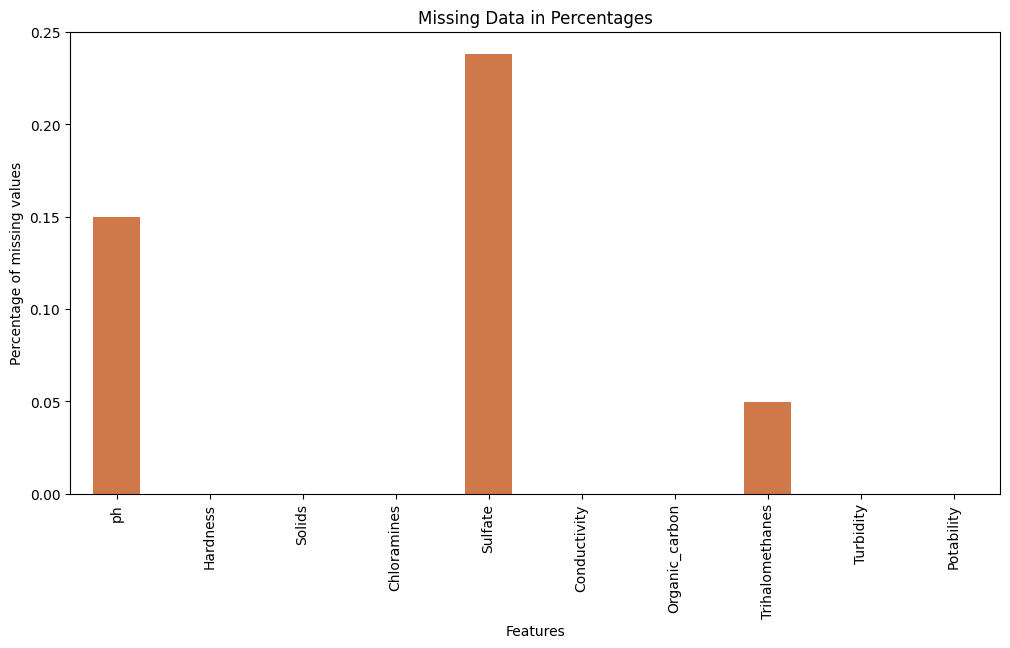

In [9]:
df.isnull().mean().plot.bar(figsize=(12,6), color="#cf7849") 
plt.ylabel('Percentage of missing values') 
plt.xlabel('Features') 
plt.title('Missing Data in Percentages')

In [10]:
df.isnull().mean()*100

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

In [11]:
df1 = df.copy()
df1['ph'].fillna(value=df1['ph'].mean(),inplace=True)
df1['Sulfate'].fillna(value=df1['Sulfate'].mean(),inplace=True)
df1['Trihalomethanes'].fillna(value=df1['Trihalomethanes'].mean(),inplace=True)

In [12]:
df1.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

### Identify outliers in the data

In [13]:
from scipy import stats

df_water = df1.copy()
df_water = df_water[(np.abs(stats.zscore(df1)) <= 3).all(axis=1)]

In [14]:
df_water.shape

(3128, 10)

Text(0.5, 1.01, 'Water Quality Box-Plot (after outlier trimming)')

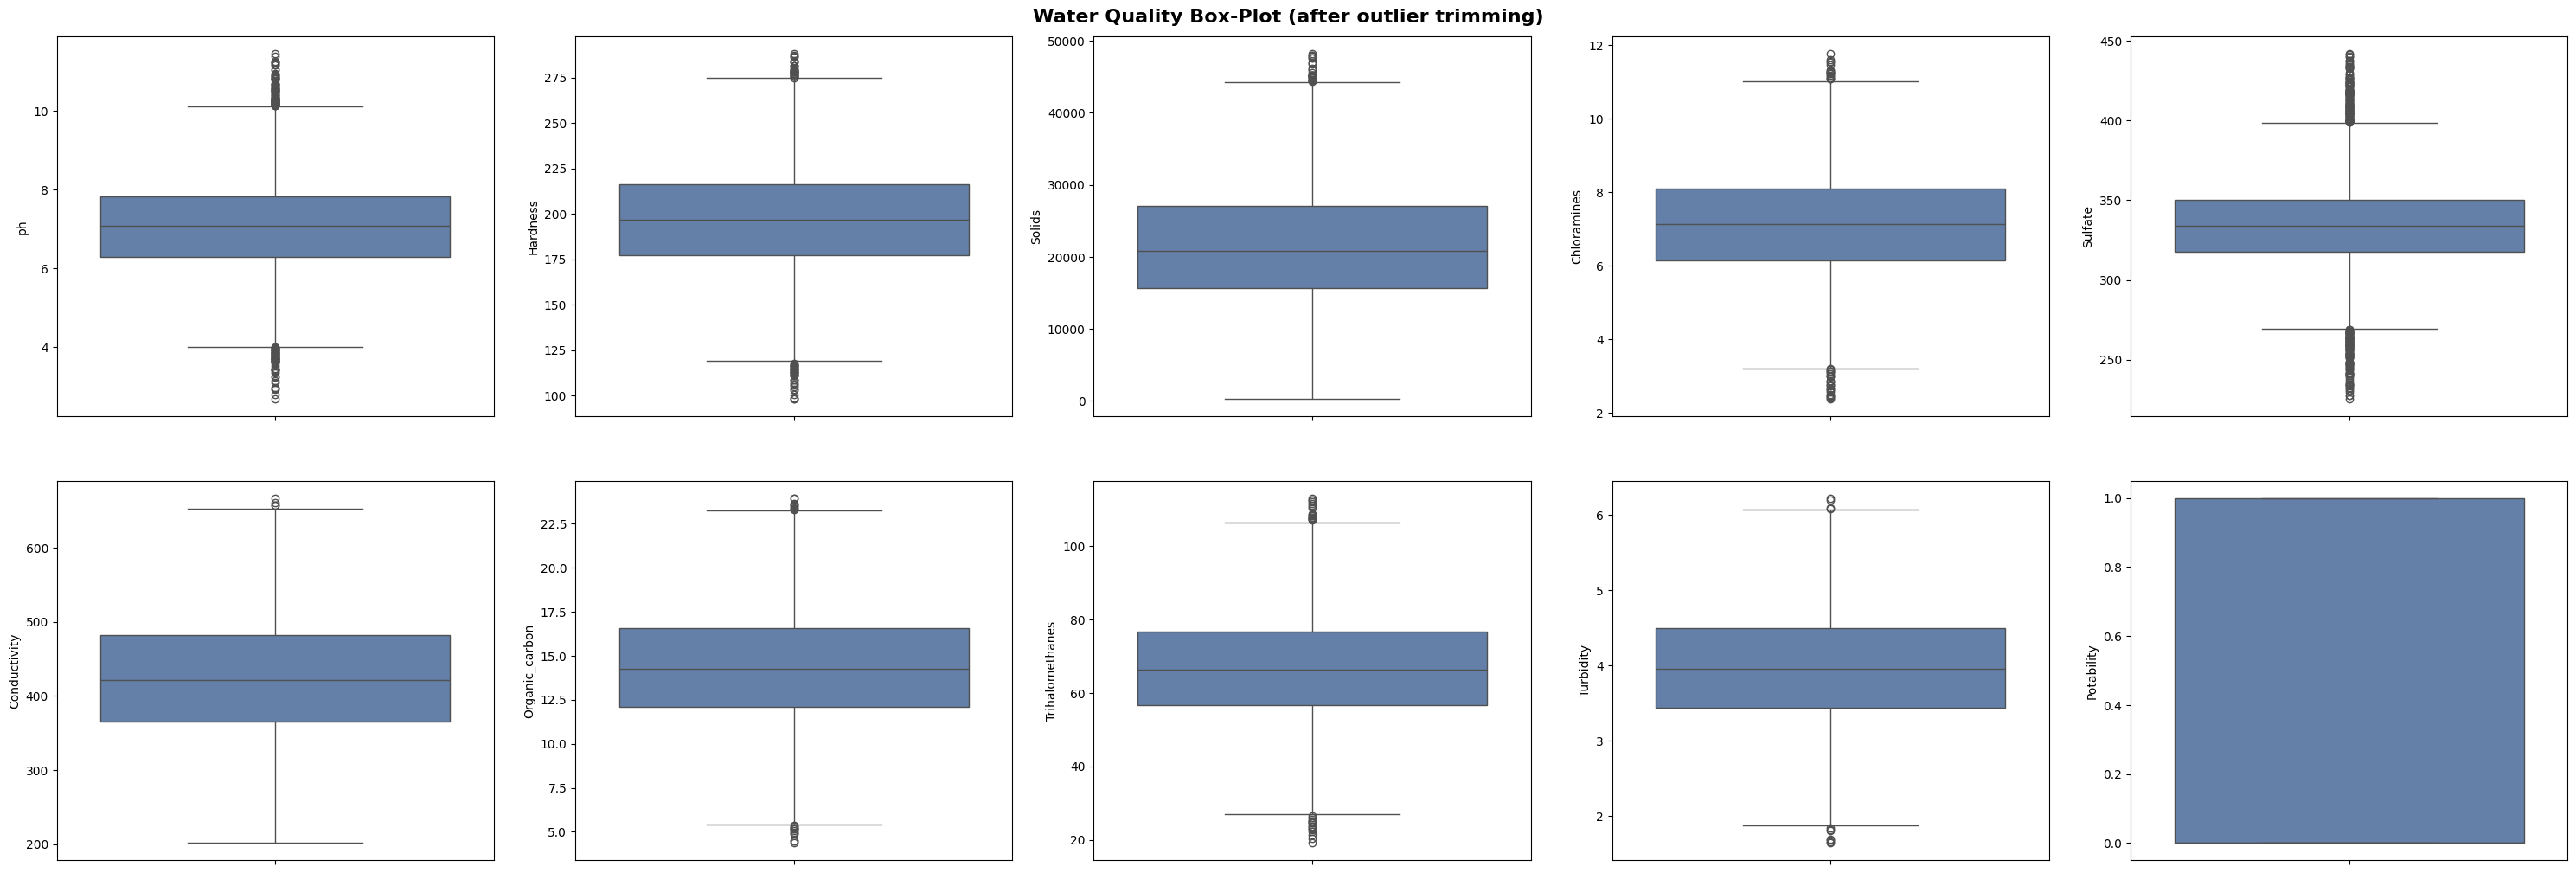

In [15]:
fig, ax = plt.subplots(ncols=5, nrows=2, figsize=(30,10))
index = 0
ax = ax.flatten()

for attributeCol, value in df_water.items():
    sns.boxplot(y=attributeCol, data=df_water, ax=ax[index], color='#597eb3')
    index += 1
plt.tight_layout(pad=1.5, w_pad=1.5, h_pad=5.0)
plt.suptitle('Water Quality Box-Plot (after outlier trimming)',y=1.01, size = 16, color = 'black', weight='bold')

### Identify corrleation between variables

In [16]:
def FunctionAnova(inpData, TargetVariable, attributeList):
    from scipy.stats import f_oneway

    SelectedPredictors=[]
    
    for predictor in attributeList:
        CategoryGroupLists=inpData.groupby(TargetVariable)[predictor].apply(list)
        AnovaResults = f_oneway(*CategoryGroupLists)
        
        # If p-value <0.05, that means we reject H0
        if (AnovaResults[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, ', P-Value:', AnovaResults[1])
            SelectedPredictors.append(predictor)
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, ', P-Value:', AnovaResults[1])
    
    return(SelectedPredictors)

In [17]:
attributeColList = ['ph',	'Hardness',	'Solids',	'Chloramines',	'Sulfate',	'Conductivity',	'Organic_carbon',	'Trihalomethanes',	'Turbidity']

FunctionAnova(inpData=df_water, TargetVariable='Potability', attributeList=attributeColList)

ph is NOT correlated with Potability , P-Value: 0.7393007692679345
Hardness is NOT correlated with Potability , P-Value: 0.5152019551100953
Solids is NOT correlated with Potability , P-Value: 0.24376029399252427
Chloramines is NOT correlated with Potability , P-Value: 0.38895878135633166
Sulfate is NOT correlated with Potability , P-Value: 0.8121224592001397
Conductivity is NOT correlated with Potability , P-Value: 0.67278748123374
Organic_carbon is NOT correlated with Potability , P-Value: 0.29594883023494456
Trihalomethanes is NOT correlated with Potability , P-Value: 0.6801397413373995
Turbidity is NOT correlated with Potability , P-Value: 0.8294778118624652


[]

### Identify skweness in the data

In [18]:
skewness = df1.skew()

# Display skewness values
print("Skewness of columns:\n", skewness)

skewed_columns = skewness[abs(skewness) > 1].index.tolist()
print("Skewed columns:", skewed_columns if skewed_columns else "None")

# Display the number of skewed columns
print("Number of skewed columns:", len(skewed_columns))


Skewness of columns:
 ph                 0.027796
Hardness          -0.039342
Solids             0.621634
Chloramines       -0.012098
Sulfate           -0.041184
Conductivity       0.264490
Organic_carbon     0.025533
Trihalomethanes   -0.085161
Turbidity         -0.007817
Potability         0.450784
dtype: float64
Skewed columns: None
Number of skewed columns: 0


### The distribution of Potability

In [19]:
# Distribution of 'Potability'
potability_counts = df1['Potability'].value_counts()
print("Distribution of Potability:\n", potability_counts)

Distribution of Potability:
 Potability
0    1998
1    1278
Name: count, dtype: int64


### Feature Transformation

In [20]:
df1.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [21]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()
df_robust_scaled = pd.DataFrame(robust_scaler.fit_transform(df1.drop(columns=['Potability'])), columns=df1.drop(columns=['Potability']).columns)
df_robust_scaled['Potability'] = df1['Potability']
df_robust_scaled.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,0.000000,0.198981,-0.011702,0.085492,1.043542,1.227178,-0.854560,1.028759,-0.935210,0
1,-2.113014,-1.696382,-0.196962,-0.249088,0.000000,1.473406,0.214093,-0.502884,0.514449,0
2,0.639503,0.684850,-0.087287,1.079558,0.000000,-0.028251,0.590024,0.001189,-0.847715,0
3,0.776180,0.437145,0.093483,0.467446,0.694190,-0.505079,0.939076,1.695662,0.635242,0
4,1.263161,-0.398477,-0.252771,-0.293690,-0.710100,-0.202262,-0.592197,-1.718287,0.113188,0


### Save the cleaned data

In [22]:
df_robust_scaled.to_csv('cleaned_data.csv', index=False)

### Hypothesis Testing

In [23]:
data = 'cleaned_data.csv'  
data = pd.read_csv(data)

median_ph = data['ph'].median()
high_ph_group = data[data['ph'] > median_ph]
low_ph_group = data[data['ph'] <= median_ph]

# Perform T-test on Solids between the two groups
ttest_result = ttest_ind(high_ph_group['Solids'], low_ph_group['Solids'])

# Print the result
print(ttest_result)

TtestResult(statistic=-2.423900021156605, pvalue=0.015408668058377182, df=3274.0)
